# Dataset: NASA C-MAPSS | Desgaste de motores turbofan
El dataset contiene datos simulados de motores turbofan de avión, generados por NASA con su simulador C-MAPSS. Cada motor arranca en estado sano y se degrada con el uso hasta llegar a la falla, reportando en cada ciclo operativo lecturas de 21 sensores junto con 3 configuraciones operativas.

Se ofrecen 4 escenarios distintos **(FD001 a FD004)**, que combinan diferentes cantidades de condiciones operativas y modos de falla, cada uno dividido en un set de entrenamiento (con la vida completa de cada motor) y uno de test (con series truncadas antes de la falla).

A continuación extraemos los datos y los formateamos:

In [63]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download('bishals098/nasa-turbofan-engine-degradation-simulation')

col_names = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)] # Columns 3-5: Operational settings (flight altitude, throttle resolver angle, etc.)
    + [f'sensor_{i}' for i in range(1, 22)] # Columns 6-26: Sensor measurements (temperatures, pressures, speeds, ratios)
)

def cargar_escenario(escenario):
    train = pd.read_csv(f'{path}/train_{escenario}.txt', sep=r'\s+', header=None, names=col_names)
    train['escenario'] = escenario
    train['unit_id'] = train['escenario'] + '_' + train['unit_number'].astype(str)
    return train

escenarios = ['FD001', 'FD002', 'FD003', 'FD004']
datos = {e: cargar_escenario(e) for e in escenarios}

Using Colab cache for faster access to the 'nasa-turbofan-engine-degradation-simulation' dataset.


## Vida útil entre diferentes escenarios
Me interesa analizar qué escenario identificó mayor vida útil. Puedo aprovechar el campo de **time_in_cycles** de los archivos de entrenamiento ya que indican el ciclo de falla de cada motor.

In [64]:
df_train_all = pd.concat(
    [datos[e][['unit_number', 'time_in_cycles', 'escenario', 'unit_id']] for e in escenarios],
    ignore_index=True
)

vida_util_todos = df_train_all.groupby(['escenario', 'unit_id'])['time_in_cycles'].max()
vida_util_todos.groupby('escenario').describe()

,count,mean,std,min,25%,50%,75%,max
escenario,,,,,,,,
FD001,100.0,206.310000,46.342749,128.0,177.00,199.0,229.25,362.0
FD002,260.0,206.765385,46.782198,128.0,174.00,199.0,230.25,378.0
FD003,100.0,247.200000,86.483840,145.0,189.75,220.5,279.75,525.0
FD004,249.0,245.979920,73.110800,128.0,190.00,234.0,290.00,543.0


Realizamos un diagrama para observar la distribución de muestras que dieron los resultados anteriores:

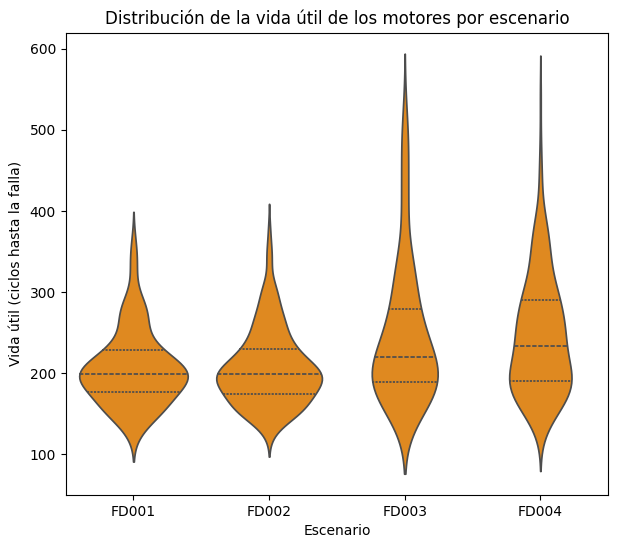

In [65]:
vida_util_df = vida_util_todos.reset_index()
vida_util_df.columns = ['escenario', 'unit_id', 'vida_util']

fig, ax = plt.subplots(figsize=(7,6))
sns.violinplot(data=vida_util_df, x='escenario', y='vida_util', ax=ax, inner='quartile', color="darkorange")
ax.set_title('Distribución de la vida útil de los motores por escenario')
ax.set_xlabel('Escenario')
ax.set_ylabel('Vida útil (ciclos hasta la falla)')
plt.show()

Vemos que FD001 y FD002 a simple vista parecen bastante similares. Lo mismo ocurre con FD003 y FD004. Sus similitudes se ven en el valor de media, percentiles y distribución.

## Variabilidad de los sensores

Antes de seguir explorando, quiero ver qué sensores realmente aportan información. En el README mencionan que hay sensores que se mantienen casi constantes durante toda la vida del motor, así que calculo el desvío estándar de cada uno para identificarlos.

Lo acoto al escenario FD001 para fines prácticos pero podría hacerse el mismo análisis para demás escenarios:

In [66]:
sensores = [f'sensor_{i}' for i in range(1, 22)]
df_train_fd001 = datos['FD001']

variabilidad_normalizada = (df_train_fd001[sensores].std() / df_train_fd001[sensores].mean()).abs().sort_values()
variabilidad_normalizada

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_1,1.260368e-13
sensor_5,2.321956e-13
sensor_10,3.585253e-13
sensor_16,5.188105e-13
sensor_8,2.972471e-05
sensor_13,3.011559e-05
sensor_6,6.427569e-05
sensor_2,7.780739e-04


Se observa un salto grande en la escala de valores: los sensores 19, 18, 1, 5, 10 y 16 tienen una variabilidad prácticamente nula (del orden de 1e-13, equivalente a cero en la práctica), lo que indica que se mantienen constantes durante toda la vida del motor y no aportan información útil para el análisis de degradación. Los sensores 8, 13 y 6 muestran una variabilidad todavía muy baja (orden de 1e-05), por lo que también podrían considerarse casi constantes. El resto de los sensores sí presenta variabilidad relevante (orden de 1e-03 en adelante), por lo que son los que se van a priorizar en el resto del análisis.

Para próximas consultas voy a trabajar con las columnas curadas de sensores relevantes (siguiendo con el escenario FD001):

In [67]:
sensores_utiles = variabilidad_normalizada[variabilidad_normalizada > 1e-4].index.tolist()
sensores_utiles

['sensor_2',
 'sensor_12',
 'sensor_7',
 'sensor_14',
 'sensor_9',
 'sensor_3',
 'sensor_17',
 'sensor_15',
 'sensor_21',
 'sensor_20',
 'sensor_11',
 'sensor_4']

## Correlación entre sensores y RUL

Ahora quiero ver qué sensores están más asociados a la degradación del motor. Para eso calculo el RUL de cada fila en train (ciclo máximo del motor menos el ciclo actual) y después la correlación de cada sensor útil contra ese valor.

In [68]:
df_train_fd001['RUL'] = (
    df_train_fd001.groupby('unit_number')['time_in_cycles'].transform('max')
    - df_train_fd001['time_in_cycles']
)

correlacion_rul = df_train_fd001[sensores_utiles + ['RUL']].corr()['RUL'].drop('RUL').sort_values()


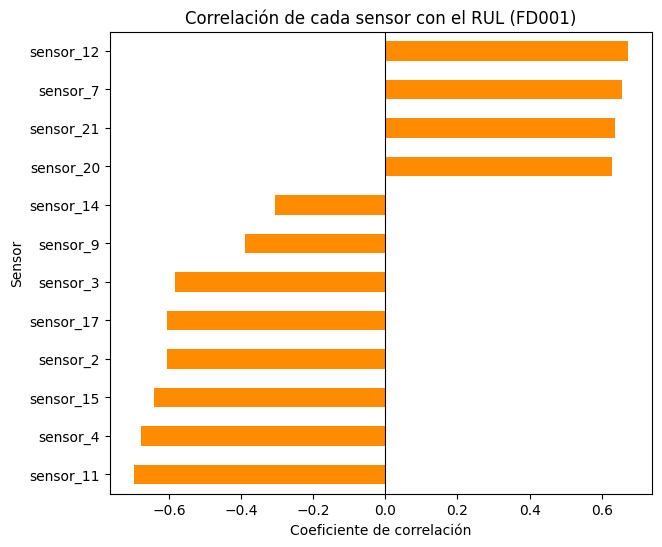

In [69]:
fig, ax = plt.subplots(figsize=(7,6))
correlacion_rul.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Correlación de cada sensor con el RUL (FD001)')
ax.set_xlabel('Coeficiente de correlación')
ax.set_ylabel('Sensor')
ax.axvline(0, color='black', linewidth=0.8)
plt.show()

Los sensores más correlacionados con el RUL son sensor_11 (Ps30, presión de salida del compresor) y sensor_4 (T50, temperatura de salida de la turbina), ambos con correlación negativa fuerte (-0.70): a medida que el motor se degrada, estos valores tienden a subir. En el extremo opuesto, sensor_12 (phi) y sensor_7 (P30) muestran correlación positiva fuerte (0.65-0.67): tienden a bajar con la degradación.

## Evolución de un sensor a lo largo de la vida de un motor

Vimos que sensor_11 es uno de los más correlacionados con el RUL. Quiero ver cómo se ve esa evolución graficamente ciclo a ciclo: tomo un motor puntual (en este caso el 1) y grafico cómo cambia sensor_11, desde que arranca sano hasta que falla.

In [70]:
motor_ejemplo = 1
datos_motor = df_train_fd001.loc[df_train_fd001['unit_number'] == motor_ejemplo]

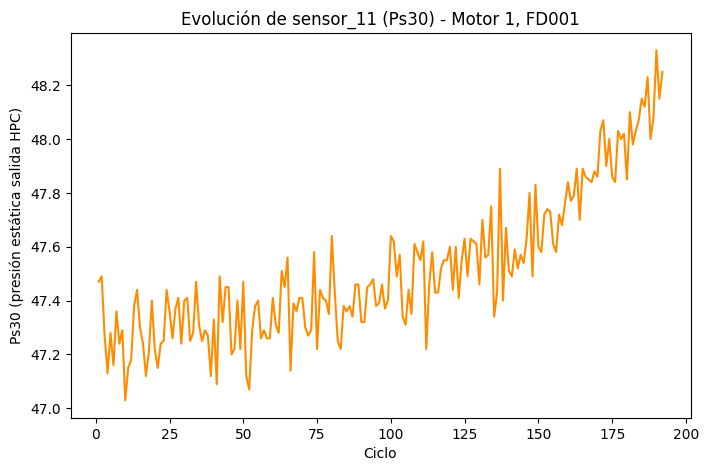

In [71]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(datos_motor['time_in_cycles'], datos_motor['sensor_11'], color='darkorange')
ax.set_title(f'Evolución de sensor_11 (Ps30) - Motor {motor_ejemplo}, FD001')
ax.set_xlabel('Ciclo')
ax.set_ylabel('Ps30 (presión estática salida HPC)')
plt.show()

Se observa que sensor_11 se mantiene relativamente estable (con ruido propio del sensor) durante aproximadamente los primeros 100 ciclos del motor. A partir de ahí comienza una tendencia ascendente que se acelera notoriamente en los últimos ciclos previos a la falla, pasando de valores cercanos a 47.6 a más de 48.2 en apenas 40-50 ciclos.

Este comportamiento demuestra un cierto patrón de degradación exponencial: el motor opera de forma estable la mayor parte de su vida útil y se degrada de forma acelerada cerca del final.

## Evolución de un sensor comparando varios motores

Antes vimos cómo evoluciona sensor_11 para un motor puntual, ahora quiero ver si ese patrón se repite en general: para eso normalizo cada motor a su porcentaje de vida transcurrido (0% a 100%), agrupo por decil de vida y calculo el promedio de sensor_11 entre los 100 motores de FD001.


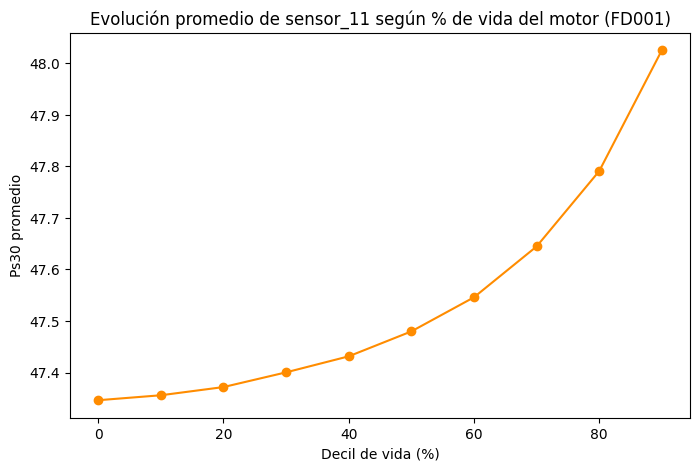

In [72]:
df_train_fd001['pct_vida'] = (
    df_train_fd001['time_in_cycles']
    / df_train_fd001.groupby('unit_number')['time_in_cycles'].transform('max')
    * 100
)

df_train_fd001['decil_vida'] = ((df_train_fd001['pct_vida'] // 10) * 10).clip(upper=90)

curva_promedio = df_train_fd001.groupby('decil_vida')['sensor_11'].mean()

fig, ax = plt.subplots(figsize=(8,5))
curva_promedio.plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title('Evolución promedio de sensor_11 según % de vida del motor (FD001)')
ax.set_xlabel('Decil de vida (%)')
ax.set_ylabel('Ps30 promedio')
plt.show()

Se observa que el promedio de sensor_11 se mantiene prácticamente estable durante la primera mitad de la vida del motor (apenas sube entre el 0% y el 50%).

A partir del 50-60% de vida la tendencia empieza a acentuarse, y la pendiente se vuelve claramente más pronunciada entre el 70% y el 90% de vida.

Este patrón confirma, ahora a nivel de todo el escenario FD001 y no solo del motor de ejemplo, la degradación acelerada cerca del final de la vida.

## Consultas en Spark

Para esta parte trabajo con los 4 escenarios combinados (df_train_all), aprovechando el volumen de datos para hacer las agregaciones de forma distribuida.

In [73]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

def cargar_escenario_rdd(escenario):
    rdd = sc.textFile(f'{path}/train_{escenario}.txt')
    rdd = rdd.map(lambda line: line.split())
    rdd = rdd.map(lambda f: (
        int(float(f[0])),   # unit_number
        float(f[1]),        # time_in_cycles
        float(f[8]),        # sensor_4
        float(f[15]),       # sensor_11
    ))
    rdd = rdd.map(lambda fields: fields + (escenario, f'{escenario}_{int(fields[0])}'))
    return rdd

rdd_train_all = sc.union([cargar_escenario_rdd(e) for e in escenarios]).cache()

TIME_IN_CYCLES = 1
SENSOR_4 = 2
SENSOR_11 = 3
ESCENARIO = 4
UNIT_ID = 5

### Cálculo  de RUL por ciclo

Calculo el RUL de cada fila: primero saco el ciclo máximo por unit_id con un reduceByKey, y después hago un join contra el RDD original para pegarle ese máximo a cada fila y poder restar (time_in_cycles del máximo).

In [74]:
max_ciclos = rdd_train_all.map(lambda f: (f[UNIT_ID], f[TIME_IN_CYCLES])).reduceByKey(lambda a, b: a if a > b else b).cache()

rdd_keyed = rdd_train_all.map(lambda f: (f[UNIT_ID], (f[TIME_IN_CYCLES], f[SENSOR_11], f[SENSOR_4], f[ESCENARIO])))

def calcular_rul(item):
    unit_id, (fila, max_ciclo) = item
    time_in_cycles, sensor_11, sensor_4, escenario = fila
    rul = max_ciclo - time_in_cycles
    return (unit_id, escenario, sensor_11, sensor_4,time_in_cycles, max_ciclo, rul)

rdd_con_rul = rdd_keyed.join(max_ciclos).map(calcular_rul)
rdd_con_rul.take(5)
# [unit_id, escenario, s11, s4, time_in_cycles, max_ciclo, rul]

[('FD001_6', 'FD001', 47.56, 1412.34, 1.0, 188.0, 187.0),
 ('FD001_6', 'FD001', 47.65, 1401.1, 2.0, 188.0, 186.0),
 ('FD001_6', 'FD001', 47.49, 1405.86, 3.0, 188.0, 185.0),
 ('FD001_6', 'FD001', 47.38, 1401.21, 4.0, 188.0, 184.0),
 ('FD001_6', 'FD001', 47.49, 1409.67, 5.0, 188.0, 183.0)]

### Motor con más y menos vida útil, por escenario

Reuso max_ciclos (ya cacheado) para encontrar, dentro de cada escenario, el motor que llegó a más ciclos y el que llegó a menos. Como max_ciclos está keyeado por unit_id, saco el escenario del propio unit_id (el prefijo antes del guion bajo) y hago dos reduceByKey por escenario: uno quedándose con el máximo y otro con el mínimo.

In [75]:
rdd_vida_por_escenario = max_ciclos.map(lambda x: (x[0].split('_')[0], (x[0], x[1])))  # (escenario, (unit_id, vida_util))

motor_mas_vida = rdd_vida_por_escenario.reduceByKey(lambda a, b: a if a[1] > b[1] else b)
motor_menos_vida = rdd_vida_por_escenario.reduceByKey(lambda a, b: a if a[1] < b[1] else b)

print("Motor con más ciclos por escenario:")
for escenario, (unit_id, vida_util) in motor_mas_vida.collect():
    print(f"  {escenario}: {unit_id} ({vida_util} ciclos)")

print("Motor con menos ciclos por escenario:")
for escenario, (unit_id, vida_util) in motor_menos_vida.collect():
    print(f"  {escenario}: {unit_id} ({vida_util} ciclos)")

Motor con más ciclos por escenario:
  FD001: FD001_69 (362.0 ciclos)
  FD003: FD003_55 (525.0 ciclos)
  FD002: FD002_112 (378.0 ciclos)
  FD004: FD004_118 (543.0 ciclos)
Motor con menos ciclos por escenario:
  FD001: FD001_39 (128.0 ciclos)
  FD003: FD003_99 (145.0 ciclos)
  FD002: FD002_244 (128.0 ciclos)
  FD004: FD004_214 (128.0 ciclos)


### Calculo de promedio de vida de los motores

Reuso max_ciclos (ya cacheado) para sacar el promedio de vida útil entre los motores de los 4 escenarios combinados, y también el promedio agrupado por escenario para comparar entre ellos.

In [76]:
promedio_vida = max_ciclos.values().mean()
print(f"Promedio general de vida útil: {promedio_vida:.2f} ciclos")

vida_por_escenario = max_ciclos.map(lambda x: (x[0].split('_')[0], x[1]))
promedio_por_escenario = vida_por_escenario.groupByKey().mapValues(lambda vals: sum(vals) / len(vals))

print("Promedio de vida útil por escenario:")
for escenario, promedio in sorted(promedio_por_escenario.collect()):
    print(f"  {escenario}: {promedio:.2f} ciclos")

Promedio general de vida útil: 226.18 ciclos
Promedio de vida útil por escenario:
  FD001: 206.31 ciclos
  FD002: 206.77 ciclos
  FD003: 247.20 ciclos
  FD004: 245.98 ciclos


# Conclusiones

Se analizaron los 4 escenarios del dataset C-MAPSS (FD001 a FD004), combinando consultas en Pandas y Spark sobre el desgaste de motores turbofan.

## Vida útil de los motores

- La vida útil depende principalmente del **modo de falla**, no tanto de la condición operativa.
- FD001 y FD002 (1 modo de falla) tienen distribuciones muy similares entre sí, aunque difieren en condiciones operativas (1 vs 6).
- FD003 y FD004 (2 modos de falla) muestran vidas útiles más largas y mucho más variables.
- El máximo y el promedio de vida útil calculados en Spark coincidieron exactamente con los de Pandas en los 4 escenarios, lo que confirma la consistencia del análisis entre ambas herramientas.

## Sensores relevantes

- 6 sensores son prácticamente constantes durante toda la vida del motor, y otros 3 tienen variabilidad mínima. No aportan información útil.
- sensor_11 (Ps30) y sensor_4 (T50) son los más correlacionados con el RUL en escenarios de una sola condición operativa.
- Esto tiene sentido físico: ambos reflejan la pérdida de presión y eficiencia típica del desgaste del compresor (HPC), el modo de falla simulado en estos datasets.

## Efecto de las condiciones operativas

- El análisis de correlación sensor-RUL se hizo sobre FD001, que tiene una única condición operativa. En FD002 y FD004, con 6 condiciones operativas, es esperable que esa correlación se diluya si no se normalizan los sensores según la condición, ya que el valor crudo del sensor pasa a reflejar tanto el régimen operativo como la degradación.

## Conclusión general

El modo de falla y las diferencias en variabilidad de los sensores fueron los factores que más influyeron en los resultados obtenidos. Trabajar con estos datos sin tenerlos en cuenta puede llevar a interpretaciones erróneas sobre qué está indicando realmente cada sensor.